In [20]:
# Importar las librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
# Cargar el dataset de ventas de videojuegos
df = pd.read_csv("../data/videogames_sales_1980_2016.csv")

In [22]:
# Vista de las primeras filas
df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
# Crear una copia de trabajo para la limpieza
df_clean = df.copy()

# Estandarizar nombres de columnas
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
)

# Comprobar dimensiones iniciales
print("Dimensión inicial:", df_clean.shape)

# Ver nombres de columnas
df_clean.columns

Dimensión inicial: (16719, 16)


Index(['name', 'platform', 'year_of_release', 'genre', 'publisher', 'na_sales',
       'eu_sales', 'jp_sales', 'other_sales', 'global_sales', 'critic_score',
       'critic_count', 'user_score', 'user_count', 'developer', 'rating'],
      dtype='str')

In [24]:
# Revisar y eliminar duplicados exactos
duplicados = df_clean.duplicated().sum()
print("Duplicados exactos:", duplicados)

df_clean = df_clean.drop_duplicates()

# Limpiar espacios en blanco en columnas de texto
cols_texto = df_clean.select_dtypes(include=["object", "string"]).columns
for col in cols_texto:
    df_clean[col] = df_clean[col].str.strip()

df_clean.shape

Duplicados exactos: 0


(16719, 16)

In [25]:
# Ajustar tipos de datos
df_clean["year_of_release"] = df_clean["year_of_release"].astype("Int64")
df_clean["user_score"] = pd.to_numeric(df_clean["user_score"], errors="coerce")
df_clean["critic_score"] = pd.to_numeric(df_clean["critic_score"], errors="coerce")
df_clean["critic_count"] = pd.to_numeric(df_clean["critic_count"], errors="coerce")
df_clean["user_count"] = pd.to_numeric(df_clean["user_count"], errors="coerce")

# Verificar tipos
df_clean.dtypes

name                   str
platform               str
year_of_release      Int64
genre                  str
publisher              str
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
global_sales       float64
critic_score       float64
critic_count       float64
user_score         float64
user_count         float64
developer              str
rating                 str
dtype: object

In [26]:
# Resumen de estructura, tipos y nulos por columna
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16717 non-null  str    
 1   platform         16719 non-null  str    
 2   year_of_release  16450 non-null  Int64  
 3   genre            16717 non-null  str    
 4   publisher        16665 non-null  str    
 5   na_sales         16719 non-null  float64
 6   eu_sales         16719 non-null  float64
 7   jp_sales         16719 non-null  float64
 8   other_sales      16719 non-null  float64
 9   global_sales     16719 non-null  float64
 10  critic_score     8137 non-null   float64
 11  critic_count     8137 non-null   float64
 12  user_score       7590 non-null   float64
 13  user_count       7590 non-null   float64
 14  developer        10096 non-null  str    
 15  rating           9950 non-null   str    
dtypes: Int64(1), float64(9), str(6)
memory usage: 2.1 MB


In [27]:
# Resumen de estadística descriptiva de variables numéricas
df_clean.describe()

,year_of_release,na_sales,eu_sales,jp_sales,other_sales,global_sales,critic_score,critic_count,user_score,user_count
count,16450.0,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,8137.000000,8137.000000,7590.000000,7590.000000
mean,2006.487356,0.263330,0.145025,0.077602,0.047332,0.533543,68.967679,26.360821,7.125046,162.229908
std,5.878995,0.813514,0.503283,0.308818,0.186710,1.547935,13.938165,18.980495,1.500006,561.282326
min,1980.0,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,0.000000,4.000000
25%,2003.0,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,6.400000,10.000000
50%,2007.0,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,7.500000,24.000000
75%,2010.0,0.240000,0.110000,0.040000,0.030000,0.470000,79.000000,36.000000,8.200000,81.000000
max,2020.0,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,9.700000,10665.000000


In [28]:
# Porcentaje de valores nulos por columna
nulos_porcentaje = (df_clean.isna().mean() * 100).round(1)
nulos_porcentaje.sort_values(ascending=False)

user_score         54.6
user_count         54.6
critic_score       51.3
critic_count       51.3
rating             40.5
developer          39.6
year_of_release     1.6
publisher           0.3
jp_sales            0.0
eu_sales            0.0
na_sales            0.0
genre               0.0
name                0.0
platform            0.0
other_sales         0.0
global_sales        0.0
dtype: float64

## Calidad de datos y sesgos del dataset

- Más del 50% de los juegos no tiene `user_score` ni `user_count`, y tampoco una parte muy importante tiene `critic_score` y `critic_count`. Por tanto, cualquier análisis que relacione ventas con valoraciones debe interpretarse con cautela.
- También faltan bastantes valores en `developer` y `rating`, lo que limita análisis sobre estudio desarrollador o clasificación por edades.
- `year_of_release` tiene pocos nulos en comparación con otras variables, por lo que sigue siendo útil para análisis temporal.

In [29]:
# Conteo de valores nulos por columna
df_clean.isna().sum().sort_values(ascending=False)

user_score         9129
user_count         9129
critic_score       8582
critic_count       8582
rating             6769
developer          6623
year_of_release     269
publisher            54
name                  2
genre                 2
na_sales              0
platform              0
jp_sales              0
eu_sales              0
other_sales           0
global_sales          0
dtype: int64

In [30]:
# Matriz de correlación entre ventas y puntuaciones
corr = df_clean[[
    "global_sales",
    "na_sales",
    "eu_sales",
    "jp_sales",
    "critic_score",
    "user_score",
    "critic_count",
    "user_count"
]].corr()

corr

,global_sales,na_sales,eu_sales,jp_sales,critic_score,user_score,critic_count,user_count
global_sales,1.000000,0.941010,0.901239,0.612300,0.245471,0.088139,0.303571,0.265012
na_sales,0.941010,1.000000,0.765336,0.449598,0.240755,0.086200,0.295413,0.246429
eu_sales,0.901239,0.765336,1.000000,0.435068,0.220752,0.055337,0.277533,0.283360
jp_sales,0.612300,0.449598,0.435068,1.000000,0.152593,0.125598,0.180219,0.075638
critic_score,0.245471,0.240755,0.220752,0.152593,1.000000,0.580878,0.425504,0.264376
user_score,0.088139,0.086200,0.055337,0.125598,0.580878,1.000000,0.194133,0.027044
critic_count,0.303571,0.295413,0.277533,0.180219,0.425504,0.194133,1.000000,0.362334
user_count,0.265012,0.246429,0.283360,0.075638,0.264376,0.027044,0.362334,1.000000


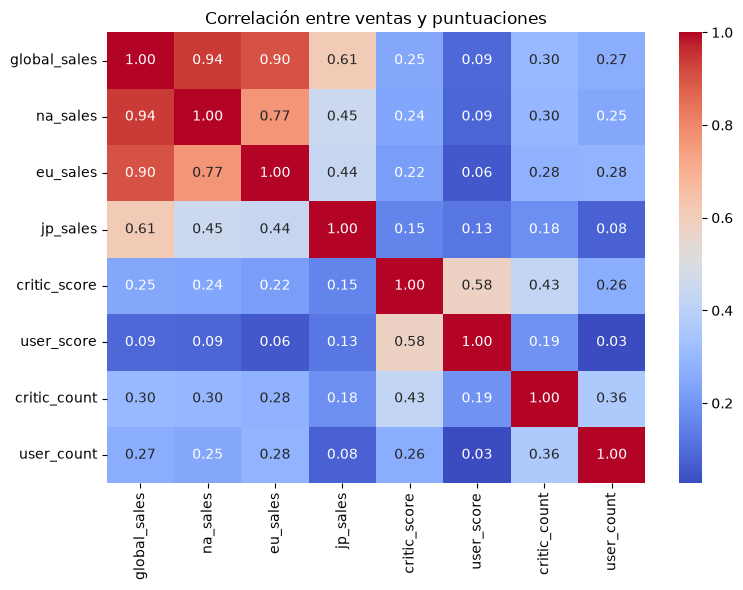

In [31]:
# Visualizar la matriz de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación entre ventas y puntuaciones")
plt.tight_layout()
plt.show()

In [32]:
# Agregar ventas globales por año de lanzamiento
ventas_por_anio = (
    df_clean.groupby("year_of_release", dropna=True)["global_sales"]
    .sum()
    .reset_index()
    .sort_values("year_of_release")
)

# Vista previa de la tabla
ventas_por_anio.head()

,year_of_release,global_sales
0,1980,11.38
1,1981,35.77
2,1982,28.86
3,1983,16.79
4,1984,50.36


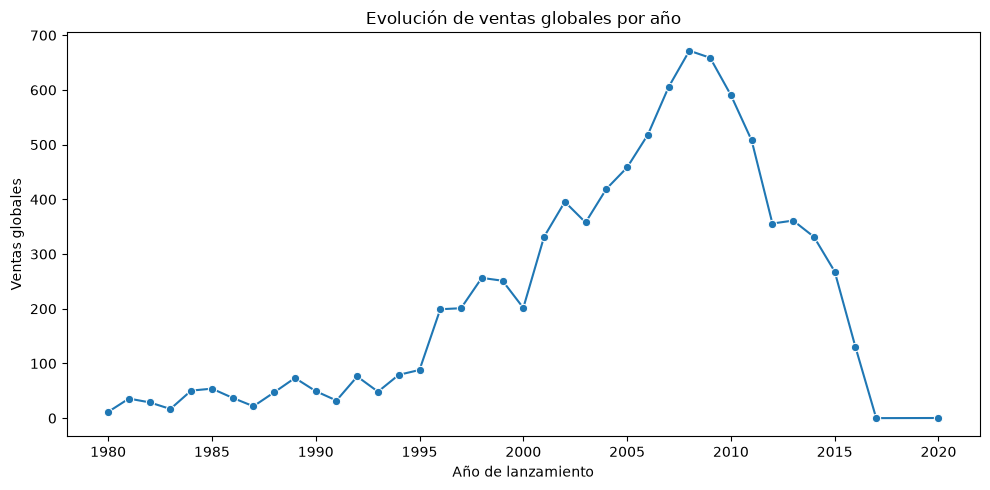

In [33]:
# Evolución de ventas globales por año
plt.figure(figsize=(10, 5))
sns.lineplot(data=ventas_por_anio, x="year_of_release", y="global_sales", marker="o")
plt.title("Evolución de ventas globales por año")
plt.xlabel("Año de lanzamiento")
plt.ylabel("Ventas globales")
plt.tight_layout()
plt.show()

In [34]:
# Ventas globales por plataforma
ventas_por_plataforma = (
    df_clean.groupby("platform", dropna=True)["global_sales"]
    .sum()
    .reset_index()
    .sort_values("global_sales", ascending=False)
)

ventas_por_plataforma.head(10)

,platform,global_sales
16,PS2,1255.64
28,X360,971.63
17,PS3,939.43
26,Wii,908.13
4,DS,807.10
15,PS,730.68
6,GBA,318.50
18,PS4,314.23
19,PSP,294.30
13,PC,260.30


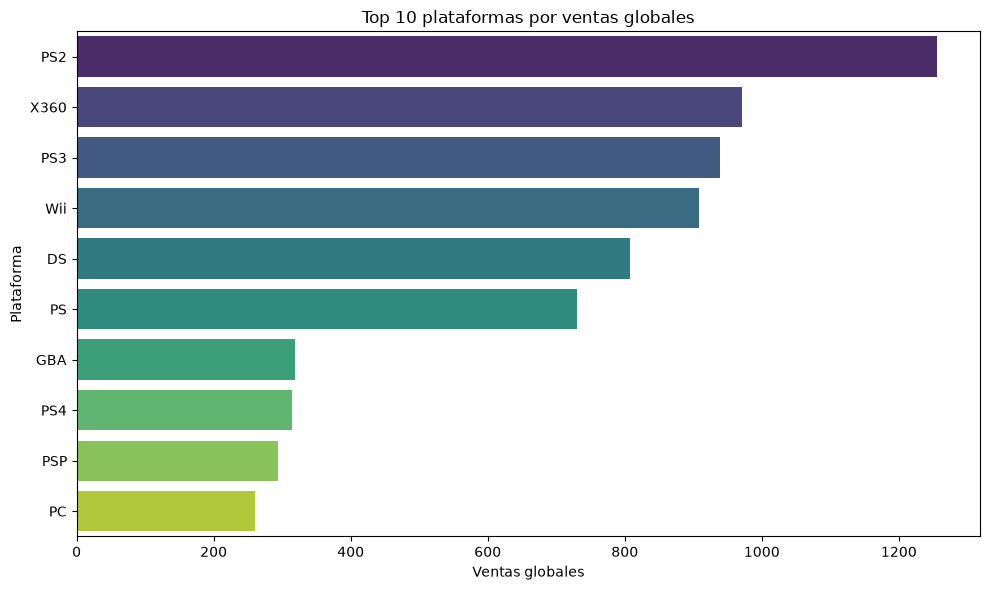

In [35]:
# Visualizar las 10 plataformas con mayores ventas globales
top_10_plataformas = ventas_por_plataforma.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_10_plataformas,
    x="global_sales",
    y="platform",
    hue="platform",
    palette="viridis",
    legend=False
)
plt.title("Top 10 plataformas por ventas globales")
plt.xlabel("Ventas globales")
plt.ylabel("Plataforma")
plt.tight_layout()
plt.show()

In [36]:
# Ventas globales por género
ventas_por_genero = (
    df_clean.groupby("genre", dropna=True)["global_sales"]
    .sum()
    .reset_index()
    .sort_values("global_sales", ascending=False)
)

ventas_por_genero.head(10)

,genre,global_sales
0,Action,1745.27
10,Sports,1332.00
8,Shooter,1052.94
7,Role-Playing,934.40
4,Platform,828.08
3,Misc,803.18
6,Racing,728.90
2,Fighting,447.48
9,Simulation,390.42
5,Puzzle,243.02


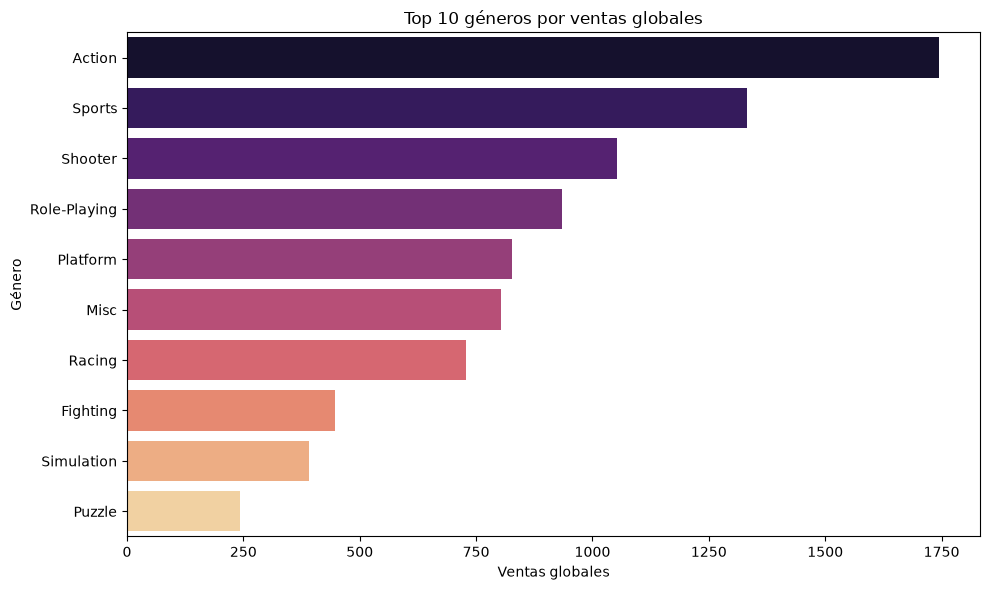

In [37]:
# Visualizar el top 10 de géneros por ventas globales
top_10_generos = ventas_por_genero.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_10_generos,
    x="global_sales",
    y="genre",
    hue="genre",
    palette="magma",
    legend=False
)
plt.title("Top 10 géneros por ventas globales")
plt.xlabel("Ventas globales")
plt.ylabel("Género")
plt.tight_layout()
plt.show()

In [38]:
# 1. Rellenamos los nulos de las columnas de texto con etiquetas claras para negocio
df_clean['rating'] = df_clean['rating'].fillna('Sin Clasificar')
df_clean['developer'] = df_clean['developer'].fillna('Desconocido')
df_clean['publisher'] = df_clean['publisher'].fillna('Desconocido')

# 2. Las puntuaciones (scores) tienen más del 50% de nulos. 
# Si las rellenamos con la media, inventamos datos y estropeamos el análisis.
# Por tanto, las dejamos como NaN (nulas), pero lo documentaremos en el dashboard.

# Eliminar las 4 filas con 'name' o 'genre' nulos para limpiar los filtros de Power BI
df_clean = df_clean.dropna(subset=['name', 'genre'])

# 3. Guardamos este nuevo dataset limpio en un archivo nuevo dentro de la carpeta data
df_clean.to_csv("../data/videogames_clean.csv", index=False)

# 4. Mensaje de confirmación para saber que se ha guardado bien
print("¡Archivo 'videogames_clean.csv' guardado con éxito en la carpeta data!")

¡Archivo 'videogames_clean.csv' guardado con éxito en la carpeta data!
